# 🧠 PyTorch Deep Learning Core Concepts: Beginner Interactive Demo

Welcome to the interactive Jupyter Notebook companion! In this notebook, we will explore key deep learning concepts using **PyTorch**, **NumPy**, and **Matplotlib**.

### 🎯 Learning Objectives:
1. **PyTorch Tensors & Autograd**: How PyTorch calculates derivatives automatically.
2. **The XOR Problem**: Why simple linear models fail and why non-linear activation functions (ReLU) are essential.
3. **The Canonical PyTorch Training Loop**: Understanding `zero_grad()`, `forward()`, `backward()`, and optimizer steps.
4. **Visualizing Predictions & Decision Boundaries**: Seeing how a neural network bends space to classify data.
5. **Overfitting & Validation Curves**: Spotting when a model starts memorizing data.


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Version: {torch.__version__}")
print("Environment successfully initialized! 🚀")


PyTorch Version: 2.10.0+cpu
Environment successfully initialized! 🚀


---
## 📍 Part 1: Tensors & Autograd (Automatic Differentiation)

In traditional math or NumPy, computing gradients requires working out formulas by hand. 
PyTorch provides **Autograd**, which tracks every math operation on a tensor with `requires_grad=True` and computes exact derivatives automatically!

Let's test the polynomial function:
$$y = 3x^2 + 2x + 1$$

Mathematically, the derivative with respect to $x$ is:
$$\frac{dy}{dx} = 6x + 2$$

At $x = 2.0$, $\frac{dy}{dx} = 6(2.0) + 2 = 14.0$. Let's verify PyTorch gets the exact same result!


In [2]:
# Define a scalar tensor with gradient tracking enabled
x = torch.tensor([2.0], requires_grad=True)

# Define the equation: y = 3*x^2 + 2*x + 1
y = 3 * (x ** 2) + 2 * x + 1

# Automatically calculate dy/dx via backpropagation
y.backward()

print(f"Value of y at x=2.0: {y.item()}")
print(f"Calculated dy/dx (PyTorch Autograd): {x.grad.item()}")
print(f"Expected dy/dx (Calculus 6*x + 2): {6*2.0 + 2}")


Value of y at x=2.0: 17.0
Calculated dy/dx (PyTorch Autograd): 14.0
Expected dy/dx (Calculus 6*x + 2): 14.0


---
## 📍 Part 2: The XOR Problem (Linear vs. Non-Linear Models)

The **XOR (Exclusive-OR)** logic gate is a classic problem in computer science. 
- Input `[0,0]` $\rightarrow$ Output `0`
- Input `[0,1]` $\rightarrow$ Output `1`
- Input `[1,0]` $\rightarrow$ Output `1`
- Input `[1,1]` $\rightarrow$ Output `0`

No single straight line can separate `1`s from `0`s in XOR space!


In [3]:
# Define XOR dataset
X_xor = torch.tensor([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]], dtype=torch.float32)
y_xor = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float32)

# 1. Try a Single Linear Neuron (No Activation / No Hidden Layer)
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
        
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

linear_model = LinearModel()
criterion = nn.BCELoss()
optimizer_lin = torch.optim.SGD(linear_model.parameters(), lr=0.5)

# Quick training of linear model
for epoch in range(1000):
    optimizer_lin.zero_grad()
    preds = linear_model(X_xor)
    loss = criterion(preds, y_xor)
    loss.backward()
    optimizer_lin.step()

print("--- Single Linear Model Predictions on XOR ---")
with torch.no_grad():
    for x_i, target in zip(X_xor, y_xor):
        pred = linear_model(x_i.unsqueeze(0)).item()
        print(f"Input: {x_i.tolist()} | Target: {target.item()} | Prediction: {pred:.4f} ({'CORRECT' if round(pred)==target.item() else 'FAILED'})")
print("Notice: A single linear neuron FAILS to learn XOR!")


--- Single Linear Model Predictions on XOR ---
Input: [0.0, 0.0] | Target: 0.0 | Prediction: 0.5000 (CORRECT)
Input: [0.0, 1.0] | Target: 1.0 | Prediction: 0.5000 (FAILED)
Input: [1.0, 0.0] | Target: 1.0 | Prediction: 0.5000 (FAILED)
Input: [1.0, 1.0] | Target: 0.0 | Prediction: 0.5000 (CORRECT)
Notice: A single linear neuron FAILS to learn XOR!


---
## 📍 Part 3: Solving XOR with a PyTorch Neural Network (MLP)

Now let's build a **Multi-Layer Perceptron (MLP)** with:
1. Input layer (2 features)
2. Hidden layer (4 neurons) + **ReLU Activation Function**
3. Output layer (1 neuron) + **Sigmoid Activation Function**


In [4]:
# Define MLP Neural Network with 1 Hidden Layer & ReLU
class XORNeuralNetwork(nn.Module):
    def __init__(self, hidden_dim=4):
        super().__init__()
        self.hidden = nn.Linear(2, hidden_dim)  # Linear Transformation 1
        self.relu = nn.ReLU()                  # Non-linear Activation
        self.output = nn.Linear(hidden_dim, 1) # Linear Transformation 2
        self.sigmoid = nn.Sigmoid()            # Scale output between 0 and 1
        
    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

mlp_model = XORNeuralNetwork(hidden_dim=4)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.1)

# Training Loop
losses = []
epochs = 500

for epoch in range(epochs):
    mlp_model.train()
    
    # 1. Zero out old gradients
    optimizer.zero_grad()
    
    # 2. Forward pass
    predictions = mlp_model(X_xor)
    
    # 3. Calculate Loss
    loss = criterion(predictions, y_xor)
    losses.append(loss.item())
    
    # 4. Backward pass (Backpropagation)
    loss.backward()
    
    # 5. Optimizer step (Update weights)
    optimizer.step()

print("--- Neural Network (MLP + ReLU) Predictions on XOR ---")
with torch.no_grad():
    for x_i, target in zip(X_xor, y_xor):
        pred = mlp_model(x_i.unsqueeze(0)).item()
        print(f"Input: {x_i.tolist()} | Target: {target.item()} | Prediction: {pred:.4f} ({'SUCCESS ✅' if round(pred)==target.item() else 'FAILED ❌'})")


--- Neural Network (MLP + ReLU) Predictions on XOR ---
Input: [0.0, 0.0] | Target: 0.0 | Prediction: 0.0001 (SUCCESS ✅)
Input: [0.0, 1.0] | Target: 1.0 | Prediction: 1.0000 (SUCCESS ✅)
Input: [1.0, 0.0] | Target: 1.0 | Prediction: 1.0000 (SUCCESS ✅)
Input: [1.0, 1.0] | Target: 0.0 | Prediction: 0.0000 (SUCCESS ✅)


---
## 📍 Part 4: Visualizing Training Loss & Decision Boundaries

Let's plot the training loss over time and visualize how the Neural Network creates a non-linear decision boundary to separate XOR classes!


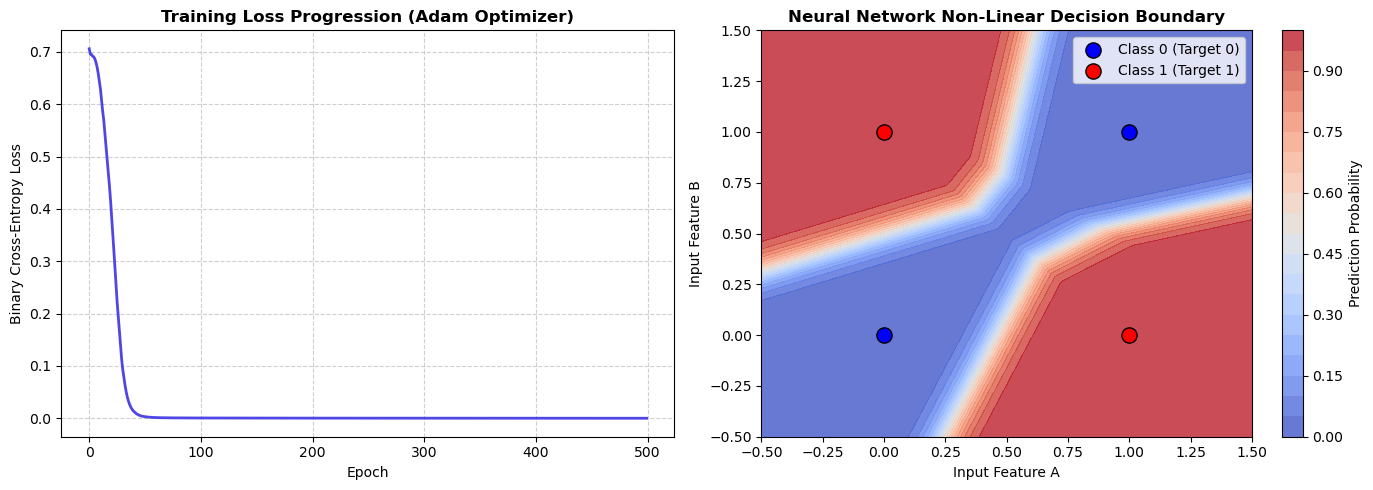

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
ax1.plot(losses, color='#4F46E5', linewidth=2)
ax1.set_title("Training Loss Progression (Adam Optimizer)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Binary Cross-Entropy Loss")
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Decision Boundary Visualization
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    Z = mlp_model(grid_tensor).reshape(xx.shape).numpy()

contour = ax2.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.8)
fig.colorbar(contour, ax=ax2, label="Prediction Probability")

# Scatter XOR Points
X_np = X_xor.numpy()
y_np = y_xor.numpy().ravel()

ax2.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], color='blue', s=120, edgecolors='k', label='Class 0 (Target 0)')
ax2.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], color='red', s=120, edgecolors='k', label='Class 1 (Target 1)')

ax2.set_title("Neural Network Non-Linear Decision Boundary", fontsize=12, fontweight='bold')
ax2.set_xlabel("Input Feature A")
ax2.set_ylabel("Input Feature B")
ax2.legend()

plt.tight_layout()
plt.show()


---
## 📍 Part 5: Understanding Overfitting & Early Stopping

In deep learning, **overfitting** happens when a network memorizes noise in the training set instead of learning the true pattern.

We can spot overfitting by comparing:
- 🔵 **Training Loss**: Loss on the dataset used for weight updates.
- 🔴 **Validation Loss**: Loss on unseen data.

When validation loss turns upward while training loss keeps falling, the network is **overfitting**!


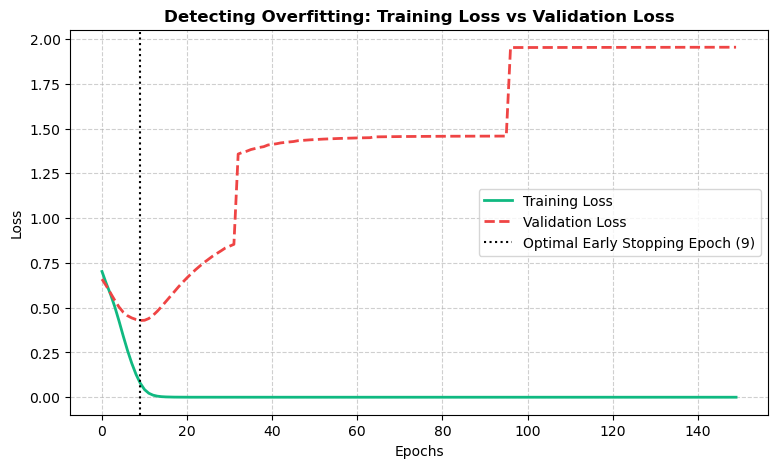

In [6]:
# Generate Synthetic Noisy Dataset
np.random.seed(42)
X_synthetic = np.random.randn(200, 10)
y_synthetic = (X_synthetic[:, 0] + X_synthetic[:, 1] * 2 > 0).astype(np.float32)

# Split into Train (30 samples - tiny to induce overfitting) and Validation (170 samples)
X_train, X_val = torch.tensor(X_synthetic[:30], dtype=torch.float32), torch.tensor(X_synthetic[30:], dtype=torch.float32)
y_train, y_val = torch.tensor(y_synthetic[:30], dtype=torch.float32).unsqueeze(1), torch.tensor(y_synthetic[30:], dtype=torch.float32).unsqueeze(1)

# Large capacity network
overfit_model = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

opt_overfit = torch.optim.Adam(overfit_model.parameters(), lr=0.01)
crit_overfit = nn.BCELoss()

train_losses, val_losses = [], []

for epoch in range(150):
    # Train step
    overfit_model.train()
    opt_overfit.zero_grad()
    t_pred = overfit_model(X_train)
    t_loss = crit_overfit(t_pred, y_train)
    t_loss.backward()
    opt_overfit.step()
    
    # Validation step
    overfit_model.eval()
    with torch.no_grad():
        v_pred = overfit_model(X_val)
        v_loss = crit_overfit(v_pred, y_val)
        
    train_losses.append(t_loss.item())
    val_losses.append(v_loss.item())

# Plot Overfitting Curves
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label='Training Loss', color='#10B981', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='#EF4444', linewidth=2, linestyle='--')
plt.axvline(x=np.argmin(val_losses), color='black', linestyle=':', label=f'Optimal Early Stopping Epoch ({np.argmin(val_losses)})')

plt.title("Detecting Overfitting: Training Loss vs Validation Loss", fontsize=12, fontweight='bold')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


---
## 🎉 Summary & Next Steps

You have now experienced the foundational pillars of PyTorch & Deep Learning!
- **Tensors & Autograd** handle the mathematical derivatives behind backpropagation.
- **Activation Functions (ReLU)** allow networks to learn non-linear patterns that linear models fail on.
- **The Training Loop** (`zero_grad` $\rightarrow$ `forward` $\rightarrow$ `loss` $\rightarrow$ `backward` $\rightarrow$ `step`) is the universal loop for all PyTorch models.
- **Validation Monitoring & Early Stopping** protect your models against overfitting.

Feel free to tweak the hidden dimensions, learning rates, or epoch counts to see how the model behaves! 🚀
